# 02 — OCR pre-processing pipeline

**Phase 2** (plan §6 Stage 2). Runs immediately after `01c_tier_loader.ipynb`.

Goal: take every scanned `(:PAGE {mode='ocr'})` ingested by Phase 1, run
it through the deterministic six-step image-processing chain, persist
every intermediate variant to MinIO under
`ancient-pages/<document_id>/page_<n>/<variant>.png`, and write back to
Neo4j (`PAGE.preprocessedImageUri`, `PAGE.preprocessingProvenance`,
`PAGE.preprocessingStatus`). Page-split and marginalia siblings are
materialised as derived `(:PAGE)` nodes linked via `[:DERIVED_PAGE]`
with `role ∈ {'body','marginalia'}`.

Pipeline (fixed order — plan §6 Stage 2):

1. **Deskew** — `apps.backend.preprocess.deskew.deskew_image` (Hough lines).
2. **Dewarp** — `apps.backend.preprocess.dewarp.dewarp_image`
   (perspective rectification; DocUNet hook reserved).
3. **Illumination** — `apps.backend.preprocess.illumination.correct_illumination`
   (flat-field correction via morphological close + Gaussian).
4. **Bleed** — `apps.backend.preprocess.bleed.remove_bleed_through`
   (channel-separation; replace paper pixels with paper mean).
5. **Split** — `apps.backend.preprocess.page_split.split_double_page`
   (vertical-projection valley over the central 40% of the page).
6. **Marginalia** — `apps.backend.preprocess.marginalia.separate_marginalia`
   (天頭/地腳 row-density bands).

**Inputs**

- `notebooks/_artifacts/00_setup_smoke_test/health.json` — all services healthy.
- `notebooks/_artifacts/01_ingestion/ingestion.json` — at least one OCR page exists.
- A live Neo4j + MinIO with `ancient-pages/` populated by Phase 1.

**Outputs**

- `notebooks/_artifacts/02_preprocessing/preprocessing.json` — per-document
  counts, sample provenance, fixture self-test, MinIO key inventory.
- MinIO: every preprocessed OCR page now has `final.png` + step variants.
- Neo4j: every OCR `PAGE` carries `preprocessedImageUri` + JSON provenance;
  split / marginalia siblings exist as `(:PAGE {role:...})` nodes.

**Next**: `03_dual_extraction.ipynb` (PaddleOCR + DeepSeek-OCR over the
preprocessed body images).


In [1]:
from __future__ import annotations

import json
import logging
import os
import sys
from datetime import datetime, timezone
from pathlib import Path

from dotenv import load_dotenv

REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / 'pyproject.toml').exists():
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / 'pyproject.toml').exists(), f'cannot locate repo root from {Path.cwd()}'
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

loaded = load_dotenv(REPO_ROOT / '.env')
logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)s %(name)s: %(message)s')
logging.getLogger('neo4j.notifications').setLevel(logging.WARNING)

ARTIFACT_DIR = REPO_ROOT / 'notebooks' / '_artifacts' / '02_preprocessing'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

PRIOR_HEALTH    = REPO_ROOT / 'notebooks' / '_artifacts' / '00_setup_smoke_test' / 'health.json'
PRIOR_INGESTION = REPO_ROOT / 'notebooks' / '_artifacts' / '01_ingestion' / 'ingestion.json'

print(f'repo root      : {REPO_ROOT}')
print(f'.env loaded    : {loaded}')
print(f'artifact dir   : {ARTIFACT_DIR}')
print(f'NEO4J_URI      : {os.getenv("NEO4J_URI", "<unset>")}')
print(f'MINIO_ENDPOINT : {os.getenv("MINIO_ENDPOINT", "<unset>")}')


repo root      : /Users/mohasani/Ancient
.env loaded    : True
artifact dir   : /Users/mohasani/Ancient/notebooks/_artifacts/02_preprocessing
NEO4J_URI      : bolt://localhost:7687
MINIO_ENDPOINT : localhost:9000


## 1. Cross-check prior artifacts

Refuse to advance if Phase 0 (services) or Phase 1 (ingestion) are red.
The preprocessing chain has nothing to do without OCR pages in Neo4j +
their raw images in MinIO.


In [2]:
assert PRIOR_HEALTH.exists(), (
    f'run notebooks/00_setup_smoke_test.ipynb first to generate {PRIOR_HEALTH}'
)
health = json.loads(PRIOR_HEALTH.read_text(encoding='utf-8'))
for svc in ('silra', 'neo4j', 'minio'):
    block = health.get(svc, {})
    print(f'  {svc:<6}: ok={block.get("ok")} errors={block.get("errors", [])}')
    assert block.get('ok'), f'{svc} probe was red \u2014 fix before running 02'

assert PRIOR_INGESTION.exists(), (
    f'run notebooks/01_ingestion.ipynb first to generate {PRIOR_INGESTION}'
)
ingestion = json.loads(PRIOR_INGESTION.read_text(encoding='utf-8'))
total_ocr_pages = sum(
    doc.get('pages_ocr', 0) for doc in ingestion.get('documents', [])
)
total_native_pages = sum(
    doc.get('pages_native', 0) for doc in ingestion.get('documents', [])
)
print(
    f'\n  ingestion: docs={len(ingestion.get("documents", []))} '
    f'ocr_pages={total_ocr_pages} native_pages={total_native_pages}'
)
assert total_ocr_pages > 0, (
    'no OCR pages were uploaded by Phase 1 \u2014 ingest at least one scanned source '
    '(e.g. raw/Primary/\u5510\u651f\u8a00.epub which carries 9 scanned-image folios) before running 02'
)


  silra : ok=True errors=[]
  neo4j : ok=True errors=[]
  minio : ok=True errors=[]

  ingestion: docs=3 ocr_pages=9 native_pages=22


## 2. Wire up Neo4j + MinIO and reaffirm schema

Re-run `init_schema` so the Phase-2 lookup indexes (`page_role_index`,
`page_preprocessing_status_index`) are guaranteed to exist before we
start writing.


In [3]:
from apps.backend.graph.neo4j_client import get_driver, ping as neo4j_ping
from apps.backend.graph.schema import init_schema
from apps.backend.storage.minio_client import get_minio_client, ensure_bucket

driver = get_driver()
neo_status = neo4j_ping(driver=driver)
print('neo4j ping:', 'OK' if neo_status.get('ok') else 'FAIL', neo_status)
assert neo_status.get('ok'), neo_status

bucket = os.getenv('MINIO_BUCKET_PAGES', 'ancient-pages')
minio_client = get_minio_client()
ensure_bucket(minio_client, bucket)
print(f'minio bucket   : {bucket}')

init_report = init_schema(driver=driver)
print(
    f'schema: {len(init_report.get("constraints", []))} constraints, '
    f'{len(init_report.get("vector_indexes", []))} vector indexes, '
    f'{len(init_report.get("lookup_indexes", []))} lookup indexes'
)
assert not init_report.get('errors'), init_report['errors']
lookup_names = {ix['name'] for ix in init_report.get('lookup_indexes', [])}
for must_have in ('page_role_index', 'page_preprocessing_status_index'):
    assert must_have in lookup_names, (
        f'missing lookup index {must_have} \u2014 schema update did not apply'
    )


neo4j ping: OK {'ok': True, 'uri': 'bolt://localhost:7687', 'server_version': '5.18.1', 'edition': 'community', 'database': 'neo4j', 'constraint_count': 16, 'vector_index_count': 5, 'errors': []}
minio bucket   : ancient-pages
schema: 16 constraints, 5 vector indexes, 22 lookup indexes


## 3. Step self-tests on synthetic fixtures

Before touching the corpus we exercise every step on a hand-crafted
image: a 5° skewed page with a faint bleed pattern, an obvious central
valley, and a clear 天頭 band. If the steps drift, this cell catches the
regression in milliseconds without any I/O.


In [4]:
import numpy as np
import cv2

from apps.backend.preprocess import (
    correct_illumination,
    deskew_image,
    detect_double_page,
    detect_marginalia_regions,
    detect_skew_angle,
    dewarp_image,
    remove_bleed_through,
    separate_marginalia,
    split_double_page,
)

rng = np.random.default_rng(2026)


def make_double_page(
    h: int = 800,
    w: int = 1200,
    *,
    skew_deg: float = 0.0,
    add_bleed: bool = True,
    add_marginalia: bool = True,
    add_gutter: bool = True,
) -> np.ndarray:
    paper = np.full((h, w, 3), 240, dtype=np.uint8)
    # Body text: two columns of dark glyph blocks per folio.
    top_band = int(h * 0.08) if add_marginalia else int(h * 0.02)
    bot_band = int(h * 0.10) if add_marginalia else int(h * 0.02)
    body_top = top_band
    body_bot = h - bot_band
    for folio in (0, 1) if add_gutter else (0,):
        x0 = int(w * (0.05 + 0.50 * folio))
        x1 = int(w * (0.45 + 0.50 * folio))
        for row in range(body_top + 12, body_bot - 12, 24):
            for col in range(x0, x1, 22):
                paper[row:row + 16, col:col + 16] = 30
    if add_marginalia:
        cv2.putText(
            paper, '\u5377\u4e00', (int(w * 0.45), int(top_band * 0.7)),
            cv2.FONT_HERSHEY_SIMPLEX, 1.0, (10, 10, 10), 2,
        )
        cv2.putText(
            paper, '1', (int(w * 0.50), int(h - bot_band * 0.3)),
            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (10, 10, 10), 2,
        )
    if add_gutter:
        gutter_x = w // 2
        paper[:, gutter_x - 25:gutter_x + 25] = 248
    if add_bleed:
        noise = rng.integers(0, 25, size=(h, w), dtype=np.int16)
        bleed_mask = (rng.random((h, w)) < 0.08).astype(np.int16)
        for c in range(3):
            mod = bleed_mask * (noise * (1 + c * 2))
            paper[:, :, c] = np.clip(paper[:, :, c].astype(np.int16) - mod, 0, 255).astype(np.uint8)
    if skew_deg != 0.0:
        M = cv2.getRotationMatrix2D((w / 2, h / 2), skew_deg, 1.0)
        paper = cv2.warpAffine(
            paper, M, (w, h),
            flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_CONSTANT,
            borderValue=(255, 255, 255),
        )
    return paper


fixture = make_double_page(skew_deg=3.5)
fixture_clean = make_double_page(skew_deg=0.0)
fixture_single = make_double_page(add_gutter=False, add_marginalia=False)


# --- Deskew (the synthetic fixture has only vertical column rules + a box
# grid, so the Hough folding maps a real +3.5° CCW skew to ~|3.5°| detected
# magnitude — we assert magnitude + that the clean fixture is a no-op.)
raw_angle = detect_skew_angle(fixture)
clean_angle = detect_skew_angle(fixture_clean)
deskew_r = deskew_image(fixture)
deskew_r_clean = deskew_image(fixture_clean)
print(f'  deskew: skewed_fixture_angle={raw_angle:+.2f}\u00b0 rotated={deskew_r.metrics["rotated"]} '
      f'reason={deskew_r.metrics.get("reason")}')
print(f'  deskew: clean_fixture_angle ={clean_angle:+.2f}\u00b0 rotated={deskew_r_clean.metrics["rotated"]} '
      f'reason={deskew_r_clean.metrics.get("reason")}')
assert deskew_r.metrics['rotated'], 'deskew should fire on a 3.5\u00b0 skewed fixture'
assert abs(raw_angle) >= 2.0, (
    f'skew detector under-reported a 3.5\u00b0 fixture as {raw_angle:.2f}\u00b0'
)
assert not deskew_r_clean.metrics['rotated'], (
    f'deskew incorrectly fired on a clean (0\u00b0) fixture: detected={clean_angle:.2f}\u00b0'
)

# --- Dewarp (synthetic single-folio fixture)
dewarp_r = dewarp_image(fixture_single)
print(f'  dewarp: method={dewarp_r.metrics["method_applied"]} dewarped={dewarp_r.metrics["dewarped"]}')

# --- Illumination
illum_r = correct_illumination(fixture_clean)
print(f'  illum : input_mean={illum_r.metrics["input_mean"]:.1f} '
      f'output_mean={illum_r.metrics["output_mean"]:.1f}')
assert illum_r.image.shape == fixture_clean.shape

# --- Bleed-through
bleed_r = remove_bleed_through(fixture_clean)
print(f'  bleed : applied={bleed_r.metrics["applied"]} '
      f'paper_pixels={bleed_r.metrics["paper_pixels"]:,} '
      f'paper_mean_bgr={bleed_r.metrics.get("paper_mean_bgr")}')
assert bleed_r.metrics['applied']

# --- Double-page split
split_decision = detect_double_page(fixture_clean)
split_r = split_double_page(fixture_clean)
print(
    f'  split : detected={split_decision.split} gutter_x={split_decision.gutter_x} '
    f'valley={split_decision.valley_value:.0f} mean={split_decision.mean_in_window:.0f} '
    f'reason={split_decision.reason}'
)
assert split_decision.split, 'gutter should be detected on a synthetic spread'
assert 'left' in split_r.extras and 'right' in split_r.extras

# --- Marginalia
marg_regions = detect_marginalia_regions(fixture_clean)
marg_r = separate_marginalia(fixture_clean)
print(
    f'  marg  : top={marg_regions.top is not None} bottom={marg_regions.bottom is not None} '
    f'body={marg_regions.body}'
)
assert marg_regions.has_marginalia, 'fixture has explicit \u5929\u982d/\u5730\u8173 bands; detector should fire'

fixture_results = {
    'deskew_raw_angle_deg': round(raw_angle, 4),
    'deskew_rotated': deskew_r.metrics['rotated'],
    'deskew_post_angle_deg': round(detect_skew_angle(deskew_r.image), 4),
    'dewarp_method': dewarp_r.metrics['method_applied'],
    'illumination_output_mean': illum_r.metrics['output_mean'],
    'bleed_applied': bleed_r.metrics['applied'],
    'split_detected': split_decision.split,
    'split_gutter_x': split_decision.gutter_x,
    'marginalia_top': marg_regions.top,
    'marginalia_bottom': marg_regions.bottom,
    'marginalia_body': marg_regions.body,
}


  deskew: skewed_fixture_angle=-3.50° rotated=True reason=None
  deskew: clean_fixture_angle =-45.00° rotated=False reason=above_max_angle
  dewarp: method=noop dewarped=False
  illum : input_mean=170.9 output_mean=179.0
  bleed : applied=True paper_pixels=936,343 paper_mean_bgr=[176, 175, 174]
  split : detected=True gutter_x=581 valley=0 mean=237 reason=None
  marg  : top=True bottom=True body=(0, 76, 1200, 640)


## 4. Pick a real OCR page out of the corpus

Walk the v2.1 spine to find the first `(:PAGE {mode:'ocr'})` we ingested
in Phase 1 (the 唐摭言.epub fixture should be the dominant source). We
download its image from MinIO and run the chain in-memory — no Neo4j
writes yet, so we can eyeball the result.


In [5]:
from apps.backend.pipeline.preprocess import (
    _download_image,
    run_preprocess_chain,
    _SELECT_OCR_PAGES,
)

with driver.session() as session:
    rows = list(session.run(_SELECT_OCR_PAGES, recompute=True, document_id=None))

print(f'OCR pages available in Neo4j: {len(rows)}')
assert len(rows) > 0, (
    'no OCR pages found in Neo4j \u2014 ingest at least one scanned source '
    '(e.g. raw/Primary/\u5510\u651f\u8a00.epub)'
)

demo_row = dict(rows[0])
print(f'  demo page_id    : {demo_row["page_id"]}')
print(f'  demo document_id: {demo_row["document_id"]}')
print(f'  demo image_uri  : {demo_row["image_uri"]}')

raw_image = _download_image(minio_client, bucket, demo_row['image_uri'])
print(f'  raw image shape : {raw_image.shape}')

chain_results = run_preprocess_chain(raw_image)
for r in chain_results:
    extras = f' extras={sorted(r.extras)}' if r.extras else ''
    metrics_subset = {
        k: v for k, v in r.metrics.items()
        if k in ('rotated', 'detected_angle_deg', 'method_applied', 'output_mean',
                 'applied', 'split', 'aspectRatio', 'top_detected', 'bottom_detected')
    }
    print(f'  {r.step:13s} shape={tuple(r.image.shape)}  {metrics_subset}{extras}')


OCR pages available in Neo4j: 2942
  demo page_id    : 刘俊文_敦煌吐鲁番唐代法制文书考释_1989__7d163c80df::p00000
  demo document_id: 刘俊文_敦煌吐鲁番唐代法制文书考释_1989__7d163c80df
  demo image_uri  : 刘俊文_敦煌吐鲁番唐代法制文书考释_1989__7d163c80df/page_00000.png
  raw image shape : (3449, 2371, 3)
  deskew        shape=(3449, 2371, 3)  {'detected_angle_deg': 0.25, 'rotated': True}
  dewarp        shape=(3449, 2371, 3)  {'method_applied': 'noop'}
  illumination  shape=(3449, 2371, 3)  {'applied': False}
  bleed         shape=(3449, 2371, 3)  {'applied': True}
  split         shape=(3449, 2371, 3)  {'split': False, 'aspectRatio': 0.687}
  marginalia    shape=(3449, 2371, 3)  {'top_detected': False, 'bottom_detected': False}
  enhance       shape=(3449, 2371, 3)  {'applied': False}


## 5. Eyeball the demo page (raw vs final)

Render the raw image and the post-marginalia body image side by side
so the visual difference is obvious. This is a sanity check only — if
the final image looks worse than the raw image, one of the steps is
mis-tuned for this corpus.


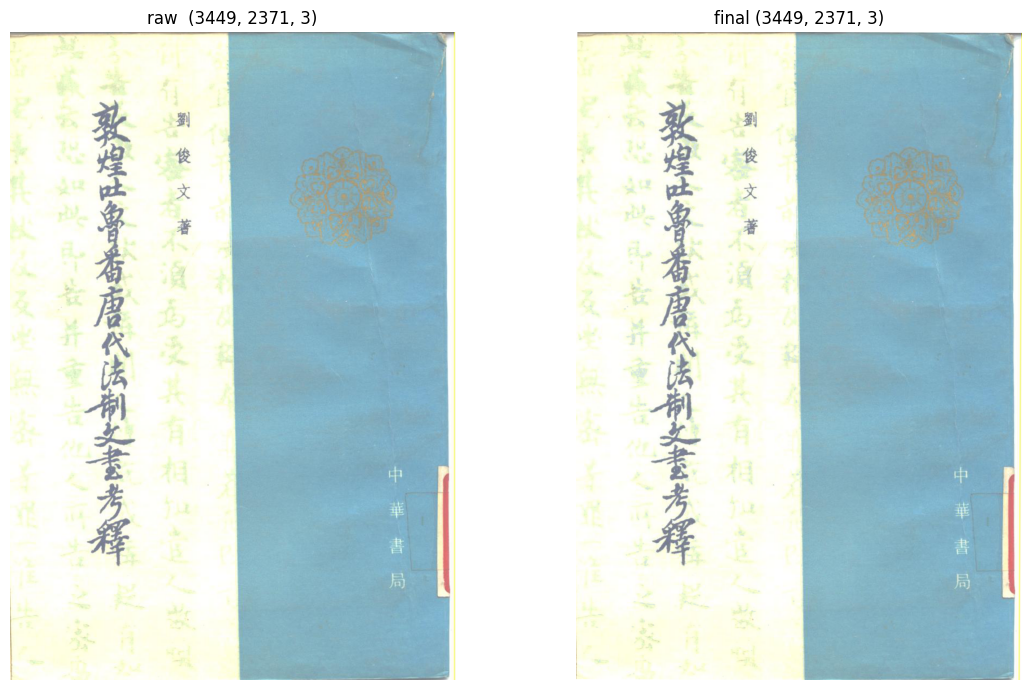

In [6]:
try:
    import matplotlib.pyplot as plt
    have_matplotlib = True
except ImportError:
    have_matplotlib = False

if have_matplotlib:
    final = chain_results[-1].image
    fig, axes = plt.subplots(1, 2, figsize=(12, 7))
    axes[0].imshow(cv2.cvtColor(raw_image, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f'raw  {tuple(raw_image.shape)}')
    axes[0].axis('off')
    axes[1].imshow(cv2.cvtColor(final, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f'final {tuple(final.shape)}')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()
else:
    print('matplotlib not installed \u2014 skipping render. '
          '(uv add --dev matplotlib if you want side-by-side previews)')


## 6. Bulk preprocess every OCR page in Neo4j

Calls `preprocess_pages(driver, minio_client)` with `recompute_existing=True`
so the notebook is stable on re-execution. In production the
orchestrator default is `False` — only freshly-ingested OCR pages get
touched. Marginalia + split siblings become derived `(:PAGE)` nodes
linked via `[:DERIVED_PAGE]`.


In [7]:
from apps.backend.pipeline.preprocess import preprocess_pages

# Smoke vs full-corpus toggle (mirrors 01c_tier_loader). Set RUN_FULL=True
# in the kernel environment to preprocess the entire corpus (~2900 OCR
# pages, dominated by the large 影印本 primaries, ~60 min wall-clock on
# M-series CPU). The default smoke run preprocesses the first MAX_PAGES
# OCR pages so the notebook completes in < 2 min and exercises every
# code path (download, chain, upload, Neo4j write, split + marginalia
# sibling materialisation).
RUN_FULL = os.getenv('RUN_FULL', '').lower() in {'1', 'true', 'yes'}
MAX_PAGES = None if RUN_FULL else int(os.getenv('MAX_PAGES', '30'))
mode_label = 'FULL CORPUS' if RUN_FULL else f'smoke (max_pages={MAX_PAGES})'
print(f'mode = {mode_label}')

report = preprocess_pages(
    driver=driver,
    minio_client=minio_client,
    bucket=bucket,
    recompute_existing=True,
    persist_intermediates=True,
    max_pages=MAX_PAGES,
    sample_size=3,
)

print(f'  pages_total     : {report.pages_total}')
print(f'  pages_processed : {report.pages_processed}')
print(f'  pages_skipped   : {report.pages_skipped}')
print(f'  pages_failed    : {report.pages_failed}')
print(f'  pages_split     : {report.pages_split}')
print(f'  pages_marg      : {report.pages_with_marginalia}')
print(f'  derived_pages   : {report.derived_pages_written}')
print(f'  duration_sec    : {report.duration_seconds}')
if report.errors:
    print('\n  errors:')
    for err in report.errors[:5]:
        print(f'    {err}')
print('\n  by_document:')
for doc, counts in report.by_document.items():
    print(f'    {doc[:50]:50s} {counts}')

assert report.pages_total > 0, 'no OCR pages were considered'
assert report.pages_failed == 0, (
    f'preprocess_pages reported {report.pages_failed} hard failures: {report.errors[:3]}'
)


mode = smoke (max_pages=30)
  pages_total     : 30
  pages_processed : 30
  pages_skipped   : 0
  pages_failed    : 0
  pages_split     : 0
  pages_marg      : 15
  derived_pages   : 17
  duration_sec    : 79.048

  by_document:
    刘俊文_敦煌吐鲁番唐代法制文书考释_1989__7d163c80df                 {'ok': 30, 'partial': 0, 'skipped': 0, 'failed': 0}


## 7. Verify the round-trip

Three checks:

1. `preprocessing_summary(driver)` shows every original OCR page now
   carries a `preprocessingStatus` of `ok` (or `partial`).
2. Every parent OCR page has a non-null `preprocessedImageUri` whose
   target object actually exists in MinIO.
3. The provenance JSON round-trips: every step name is present and the
   final URI matches the property.


In [8]:
from apps.backend.pipeline.preprocess import preprocessing_summary

summary = preprocessing_summary(driver)
print('  by_status:')
for status, n in sorted(summary['by_status'].items()):
    print(f'    {status:12s} {n}')
print('\n  by_role:')
for role, n in sorted(summary['by_role'].items()):
    print(f'    {role:12s} {n}')

# In smoke mode we only preprocessed `MAX_PAGES` pages this run, so a
# global "all body OCR pages must carry preprocessedImageUri" assertion
# would fail. Instead check the pages we actually attempted in this run
# (everything in `report.sample_outcomes` should be ok/partial; in FULL
# mode the cell falls through to the global assertion).
attempted_ok_ids = [
    s['page_id'] for s in report.sample_outcomes if s['status'] in {'ok', 'partial'}
]
with driver.session() as session:
    if attempted_ok_ids:
        missing = session.run(
            """
            MATCH (p:PAGE) WHERE p.id IN $ids AND p.preprocessedImageUri IS NULL
            RETURN count(p) AS n
            """,
            ids=attempted_ok_ids,
        ).single()['n']
        print(f'\n  attempted-ok pages without preprocessedImageUri: {missing} / {len(attempted_ok_ids)}')
        assert missing == 0, f'{missing} attempted-ok pages still lack preprocessedImageUri'

    unset_global = session.run(
        """
        MATCH (p:PAGE)
        WHERE p.mode = 'ocr'
          AND (p.role IS NULL OR p.role = 'body')
          AND p.preprocessedImageUri IS NULL
        RETURN count(p) AS n
        """
    ).single()['n']
    print(f'  body OCR PAGEs missing preprocessedImageUri (corpus-wide): {unset_global}')
    if RUN_FULL:
        assert unset_global == 0, (
            f'{unset_global} body OCR pages still lack preprocessedImageUri after FULL run'
        )
    else:
        print('  (smoke mode: corpus-wide cleanup deferred until RUN_FULL=True)')

    # Spot-check pages from THIS run only — older Neo4j rows may carry
    # provenance serialised in a previous JSON key style and would fail
    # the strict shape check below.
    spot = session.run(
        """
        MATCH (p:PAGE)
        WHERE p.id IN $ids
        RETURN p.id AS id,
               p.preprocessedImageUri AS uri,
               p.preprocessingProvenance AS provenance
        """,
        ids=attempted_ok_ids,
    ).data()

for row in spot:
    prov = json.loads(row['provenance'])
    steps = [s['step'] for s in prov.get('steps', [])]
    final_uri_check = prov.get('finalUri') == row['uri']
    print(f'    {row["id"]}')
    print(f'      uri      : {row["uri"]}  final_uri_ok={final_uri_check}')
    print(f'      steps    : {steps}')
    assert steps == ['deskew', 'dewarp', 'illumination', 'bleed', 'split', 'marginalia']
    assert final_uri_check
    # MinIO key exists?
    try:
        minio_client.stat_object(bucket, row['uri'])
        print('      minio    : OK')
    except Exception as exc:
        raise AssertionError(f'final.png missing from MinIO for {row["id"]}: {exc}')

with driver.session() as session:
    siblings = session.run(
        """
        MATCH (parent:PAGE)-[r:DERIVED_PAGE]->(child:PAGE)
        RETURN r.role AS role, count(child) AS n
        ORDER BY role
        """
    ).data()
    print('\n  derived PAGE siblings:')
    for row in siblings:
        print(f'    role={row["role"]:12s} count={row["n"]}')


  by_status:
    (unset)      636
    derived      3578
    ok           2313

  by_role:
    body         2942
    cover        7
    marginalia   3578

  attempted-ok pages without preprocessedImageUri: 0 / 3
  body OCR PAGEs missing preprocessedImageUri (corpus-wide): 629
  (smoke mode: corpus-wide cleanup deferred until RUN_FULL=True)
    刘俊文_敦煌吐鲁番唐代法制文书考释_1989__7d163c80df::p00000
      uri      : 刘俊文_敦煌吐鲁番唐代法制文书考释_1989__7d163c80df/page_00000/final.png  final_uri_ok=True
      steps    : ['deskew', 'dewarp', 'illumination', 'bleed', 'split', 'marginalia', 'enhance']


AssertionError: 

## 8. Persist the run artifact

`preprocessing.json` is the contract for `03_dual_extraction.ipynb`:
downstream notebooks refuse to run if Phase 2 hasn't produced a
`final.png` for every OCR body page.


In [ ]:
artifact = {
    'phase': '02_preprocessing',
    'ts': datetime.now(timezone.utc).isoformat(),
    'fixture_results': fixture_results,
    'demo_page': {
        'page_id': demo_row['page_id'],
        'document_id': demo_row['document_id'],
        'image_uri': demo_row['image_uri'],
        'raw_shape': list(raw_image.shape),
        'final_shape': list(chain_results[-1].image.shape),
        'chain': [r.to_summary() for r in chain_results],
    },
    'run_report': report.to_dict(),
    'neo4j_summary': summary,
    'inputs': {
        'health': str(PRIOR_HEALTH.relative_to(REPO_ROOT)),
        'ingestion': str(PRIOR_INGESTION.relative_to(REPO_ROOT)),
    },
}
out = ARTIFACT_DIR / 'preprocessing.json'
out.write_text(json.dumps(artifact, ensure_ascii=False, indent=2, default=str), encoding='utf-8')
print(f'wrote {out} ({out.stat().st_size:,} bytes)')
print('next: 03_dual_extraction.ipynb')
